In [1]:
import numpy as np
import matplotlib.pyplot as plt

# import energy_landscapes
from propagators_grid import propagate
import test_propagators_grid
import energy_landscapes

import importlib

In [2]:
importlib.reload(test_propagators_grid)
importlib.reload(energy_landscapes)

#test_propagators_grid.test_propagators_grid()
test_propagators_grid.test_free_energy_on_cv_grid()

(9, 1)
(9,)


[-3. -3.]
[3. 3.]


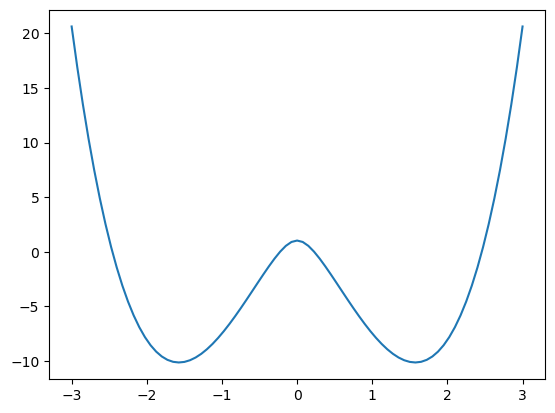

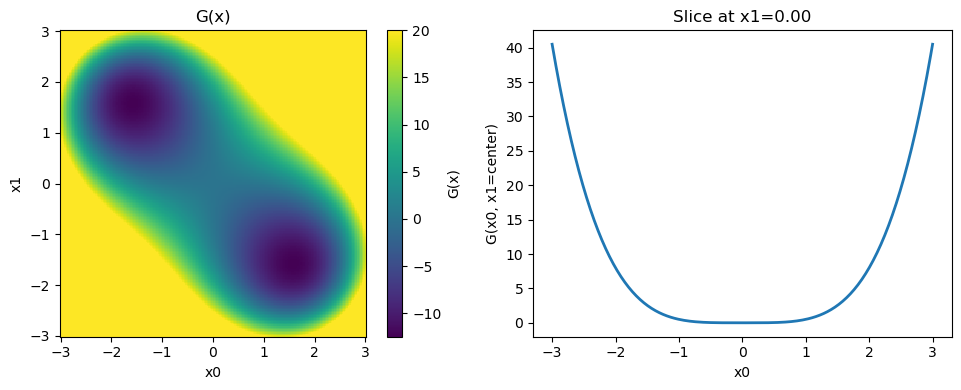

In [ ]:
importlib.reload(test_propagators_grid)
importlib.reload(energy_landscapes)

n_walkers = 4
n_dim = 2
n_cv = 1

def G1(x):
    return (x[:, 0]**2 - 3)**2 + 0.5*x[:, 1]**2

def G2(x):
    return 0.5*(x[:, 0]**2 + x[:, 1]**2)**2 + (x[:,0]*x[:,1])*10

def G(x):
    return G2(x)

def CV(x):
    return x[:, :1]

def grad_CV(x):
    n = x.shape[0]
    out = np.zeros((n, n_cv, n_dim))
    out[:, 0, 0] = 1.0
    return out

grid_n = 81
cv_min = np.array([-3.0])
cv_max = np.array([3.0])

print(np.array([cv_min[0], cv_min[0]]))
print(np.array([cv_max[0], cv_max[0]]))

cv_grid, free_energy_grid = energy_landscapes.free_energy_on_cv_grid(
        free_energy_fn=G,
        cv_fn=CV,
        coord_min=np.array([cv_min[0], cv_min[0]]),
        coord_max=np.array([cv_max[0], cv_max[0]]),
        cv_min=cv_min,
        cv_max=cv_max,
        n_grid=grid_n,
        n_micro_grid=grid_n,
        kT = 1
    )

plt.plot(cv_grid, free_energy_grid)

init_coords = np.random.uniform(-1.5, 1.5, size=(n_walkers, n_dim))
init_potentials = np.zeros((n_walkers, grid_n))
sigma = np.array([0.2])

test_propagators_grid.plot_G_surface(G, x_limits = ((cv_min[0], cv_max[0]), (cv_min[0], cv_max[0])), n=200, center=None, slice_axis=0)


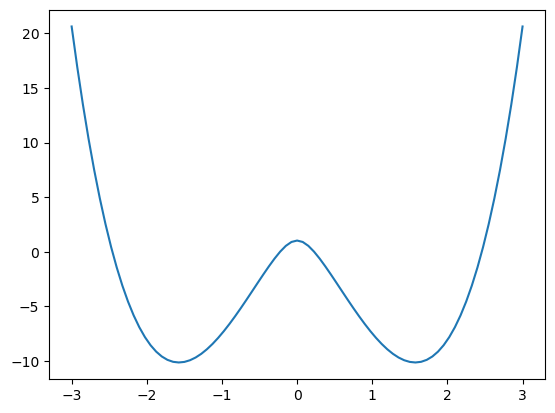

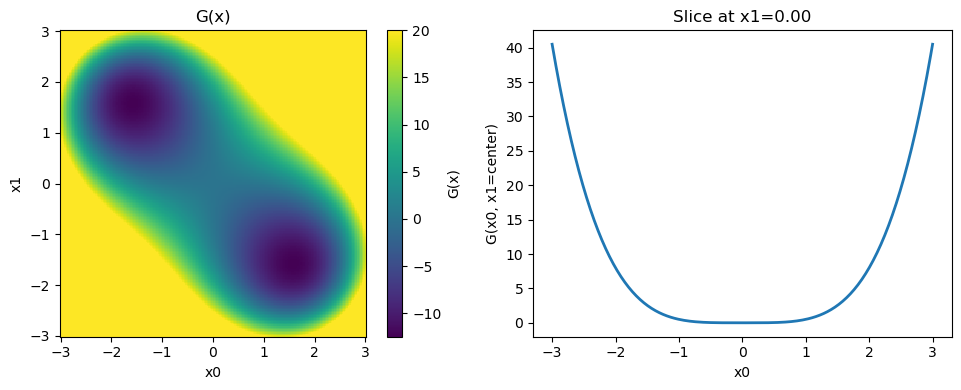

trajectories shape (4, 3000, 2)
potentials shape (4, 300, 81)
sample final coords [[ 1.8512539  -2.01174692]
 [ 2.0928438  -1.72832595]
 [-0.90959985  1.54887131]
 [-2.21389093  1.55193328]]
True True
(2,)


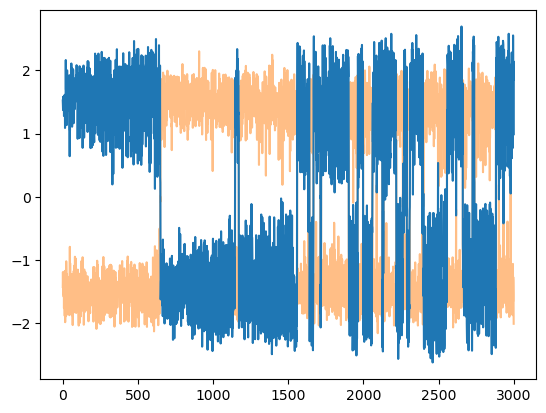

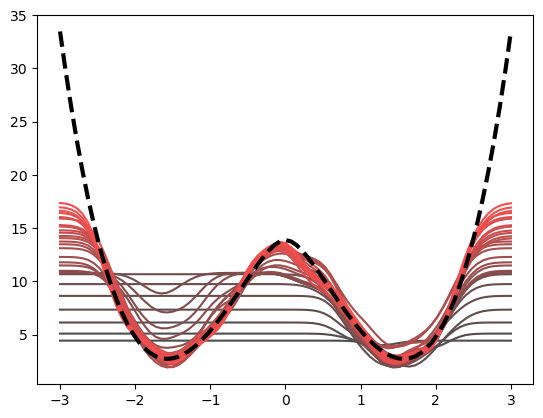

In [24]:

n_walkers = 4
n_dim = 2
n_cv = 1
T=1
kB=1
kT = kB*T

def G1(x):
    return (x[:, 0]**2 - 3)**2 + 0.5*x[:, 1]**2

def G2(x):
    return 0.5*(x[:, 0]**2 + x[:, 1]**2)**2 + (x[:,0]*x[:,1])*10

def G(x):
    return G2(x)

def CV(x):
    return x[:, :1]

def grad_CV(x):
    n = x.shape[0]
    out = np.zeros((n, n_cv, n_dim))
    out[:, 0, 0] = 1.0
    return out

grid_n = 81
cv_min = np.array([-3.0])
cv_max = np.array([3.0])

cv_grid, free_energy_grid = energy_landscapes.free_energy_on_cv_grid(
        free_energy_fn=G,
        cv_fn=CV,
        coord_min=np.array([cv_min[0], cv_min[0]]),
        coord_max=np.array([cv_max[0], cv_max[0]]),
        cv_min=cv_min,
        cv_max=cv_max,
        n_grid=grid_n,
        n_micro_grid=grid_n,
        kT = kT
    )

plt.plot(cv_grid, free_energy_grid)


init_coords = np.random.uniform(-1.5, 1.5, size=(n_walkers, n_dim))
init_potentials = np.zeros((n_walkers, grid_n))
sigma = np.array([0.2])

test_propagators_grid.plot_G_surface(G, x_limits = ((cv_min[0], cv_max[0]), (cv_min[0], cv_max[0])), n=200, center=None, slice_axis=0)

delta_T = 40

traj, pots = propagate(
    G=G, kT=kT, dt=0.01, init_coords=init_coords,
    init_potentials=init_potentials, steps_per_saved_frame=100,
    n_gaussians=300, frames_per_gaussian=10,
    CV=CV, grad_CV=grad_CV, sigma=sigma, omega=0.4, delta_T=delta_T,
    cv_min=cv_min, cv_max=cv_max
)

print('trajectories shape', traj.shape)
print('potentials shape', pots.shape)
print('sample final coords', traj[:, -1, :])
#print('max bias height walker0 over time', pots[0, :, :].max(axis=-1))
print(np.isfinite(traj).all(), np.isfinite(pots).all())


print(traj[0,0].shape)
plt.plot(traj[0,:,0], zorder=100)
plt.plot(traj[0,:,1], alpha=0.5)
plt.show()

for i, Vi in enumerate(pots[0]):
    if i%10==0:
        plt.plot(cv_grid, -Vi*(delta_T+T)/delta_T + kT*np.log(np.sum(np.exp(Vi*((delta_T+T)/delta_T)/kT))), color = [0.3+0.7*(i/len(pots[0])), 0.3, 0.3])

kT=1
plt.plot(cv_grid, free_energy_grid + kT*np.log(np.sum(np.exp(-free_energy_grid/kT))), linestyle="dashed", color="black", linewidth="3")

plt.show()



(2,)


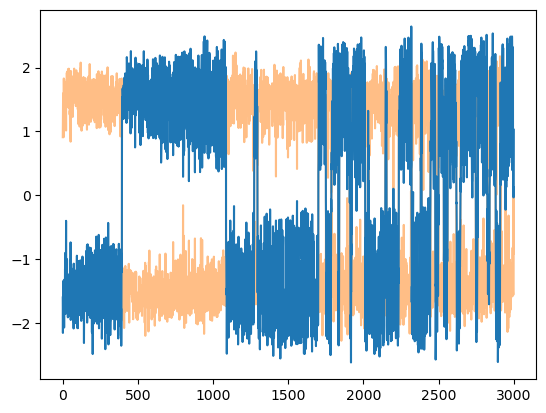

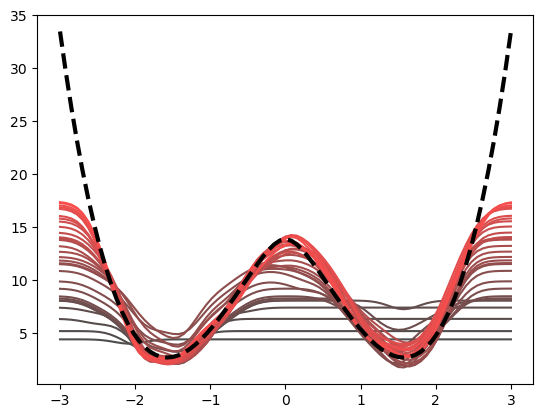

In [ ]:
print(traj[0,0].shape)
plt.plot(traj[0,:,0], zorder=100)
plt.plot(traj[0,:,1], alpha=0.5)
plt.show()

for i, Vi in enumerate(pots[0]):
    if i%10==0:
        plt.plot(cv_grid, -Vi*(delta_T+T)/delta_T + kT*np.log(np.sum(np.exp(Vi*((delta_T+T)/delta_T)/kT))), color = [0.3+0.7*(i/len(pots[0])), 0.3, 0.3])

kT=1
plt.plot(cv_grid, free_energy_grid + kT*np.log(np.sum(np.exp(-free_energy_grid/kT))), linestyle="dashed", color="black", linewidth="3")

plt.show()


In [ ]:
# quick 2-cv test
n_cv2 = 2
def CV2(x):
    return x[:, :2]
def grad_CV2(x):
    n = x.shape[0]
    out = np.zeros((n, n_cv2, n_dim))
    out[:, 0, 0] = 1.0
    out[:, 1, 1] = 1.0
    return out

sigma2 = np.array([0.3, 0.3])
grid_shape2 = (25, 25)
init_potentials2 = np.zeros((n_walkers, *grid_shape2))
cv_min2 = np.array([-3.0, -3.0])
cv_max2 = np.array([3.0, 3.0])

traj2, pots2 = propagate(
    G=G, kT=1.0, dt=0.001, init_coords=init_coords,
    init_potentials=init_potentials2, steps_per_saved_frame=5,
    n_gaussians=5, frames_per_gaussian=2,
    CV=CV2, grad_CV=grad_CV2, sigma=sigma2, omega=0.5, delta_T=5.0,
    cv_min=cv_min2, cv_max=cv_max2,
)
print('2cv trajectories shape', traj2.shape)
print('2cv potentials shape', pots2.shape)
print(np.isfinite(traj2).all(), np.isfinite(pots2).all())